In [2]:
!pip install yfinance
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [4]:
import yfinance as yf
nifty50_tickers = [
    "ADANIENT.NS", "ADANIPORTS.NS", "APOLLOHOSP.NS", "ASIANPAINT.NS", "AXISBANK.NS",
    "BAJAJ-AUTO.NS", "BAJFINANCE.NS", "BAJAJFINSV.NS", "BEL.NS", "BHARTIARTL.NS",
    "BPCL.NS", "BRITANNIA.NS", "CIPLA.NS", "COALINDIA.NS", "DRREDDY.NS",
    "EICHERMOT.NS", "ETERNAL.NS", "GRASIM.NS", "HCLTECH.NS", "HDFCBANK.NS",
    "HDFCLIFE.NS", "HEROMOTOCO.NS", "HINDALCO.NS", "HINDUNILVR.NS", "ICICIBANK.NS",
    "ITC.NS", "INDUSINDBK.NS", "INFY.NS", "INDIGO.NS", "JSWSTEEL.NS",
    "JIOFIN.NS", "KOTAKBANK.NS", "LT.NS", "M&M.NS", "MARUTI.NS",
    "MAXHEALTH.NS", "NTPC.NS", "NESTLEIND.NS", "ONGC.NS", "POWERGRID.NS",
    "RELIANCE.NS", "SBILIFE.NS", "SHRIRAMFIN.NS", "SBIN.NS", "SUNPHARMA.NS",
    "TCS.NS", "TATACONSUM.NS", "TMPV.NS", "TATASTEEL.NS", "TECHM.NS",
    "TITAN.NS", "TRENT.NS", "ULTRACEMCO.NS", "WIPRO.NS"


]

In [5]:
raw_data=yf.download(nifty50_tickers,period='2y',interval='1D',auto_adjust=True)

[*********************100%***********************]  54 of 54 completed


In [6]:
price_data=raw_data.xs('Close',level='Price',axis=1)
def get_consecutive_nan_count(col):
    is_nan = col.isnull()
    streak_id = (is_nan != is_nan.shift()).cumsum()
    nan_streaks = is_nan[is_nan].groupby(streak_id).size()
    return nan_streaks.max() if not nan_streaks.empty else 0

max_streaks = price_data.apply(get_consecutive_nan_count)

tickers_to_drop = max_streaks[max_streaks > 5].index.tolist()
print(f"Dropping: {tickers_to_drop}")

Dropping: ['TMPV.NS']


In [7]:
price_df=raw_data.drop(columns=tickers_to_drop,level=1)

In [8]:
close_df=price_df['Close']
close_df.isnull().sum()

Ticker
ADANIENT.NS      0
ADANIPORTS.NS    0
APOLLOHOSP.NS    0
ASIANPAINT.NS    0
AXISBANK.NS      0
BAJAJ-AUTO.NS    0
BAJAJFINSV.NS    0
BAJFINANCE.NS    0
BEL.NS           0
BHARTIARTL.NS    0
BPCL.NS          0
BRITANNIA.NS     0
CIPLA.NS         0
COALINDIA.NS     0
DRREDDY.NS       0
EICHERMOT.NS     0
ETERNAL.NS       5
GRASIM.NS        0
HCLTECH.NS       0
HDFCBANK.NS      0
HDFCLIFE.NS      0
HEROMOTOCO.NS    0
HINDALCO.NS      0
HINDUNILVR.NS    0
ICICIBANK.NS     0
INDIGO.NS        1
INDUSINDBK.NS    0
INFY.NS          0
ITC.NS           0
JIOFIN.NS        5
JSWSTEEL.NS      0
KOTAKBANK.NS     0
LT.NS            0
M&M.NS           0
MARUTI.NS        0
MAXHEALTH.NS     0
NESTLEIND.NS     0
NTPC.NS          0
ONGC.NS          0
POWERGRID.NS     0
RELIANCE.NS      0
SBILIFE.NS       0
SBIN.NS          0
SHRIRAMFIN.NS    0
SUNPHARMA.NS     0
TATACONSUM.NS    0
TATASTEEL.NS     0
TCS.NS           0
TECHM.NS         0
TITAN.NS         0
TRENT.NS         0
ULTRACEMCO.NS    0
WIPRO

In [9]:
close_prices=close_df.ffill()

In [10]:
df_returns=np.log(close_prices/close_prices.shift(1))
log_returns=df_returns.dropna()
log_returns.index=log_returns.index.rename('DATE')
log_returns.head()

Ticker,ADANIENT.NS,ADANIPORTS.NS,APOLLOHOSP.NS,ASIANPAINT.NS,AXISBANK.NS,BAJAJ-AUTO.NS,BAJAJFINSV.NS,BAJFINANCE.NS,BEL.NS,BHARTIARTL.NS,...,SHRIRAMFIN.NS,SUNPHARMA.NS,TATACONSUM.NS,TATASTEEL.NS,TCS.NS,TECHM.NS,TITAN.NS,TRENT.NS,ULTRACEMCO.NS,WIPRO.NS
DATE,,,,,,,,,,,,,,,,,,,,,
2024-05-16,-0.002660,0.005367,0.014074,0.000124,0.009924,-0.003522,0.017030,0.010002,0.021456,0.026518,...,0.008028,0.005810,0.028453,0.001810,0.012524,0.025907,0.019796,0.015268,0.009833,0.013330
2024-05-17,0.006178,-0.006976,0.003593,-0.001476,0.001798,-0.010327,-0.007074,-0.002932,0.042384,-0.000483,...,0.013970,-0.003195,-0.004146,0.008702,-0.017285,-0.001952,0.008140,0.008211,0.018496,-0.007456
2024-05-21,0.018453,0.036606,-0.000807,0.014801,-0.003247,0.004545,-0.001389,0.002294,0.099441,-0.000111,...,0.000695,0.006217,-0.001142,0.040977,-0.003632,0.014072,0.004705,0.007042,-0.010259,-0.000217
2024-05-22,0.007494,-0.005283,-0.013558,0.011834,-0.010293,-0.001719,0.000884,0.000252,0.033889,0.002674,...,-0.015499,-0.001071,0.023846,-0.006041,0.003084,0.004898,0.002026,-0.003684,0.010714,0.000867
2024-05-23,0.075508,0.046189,0.017216,0.006218,0.034264,0.017773,0.015349,0.012099,0.017130,0.019215,...,0.026895,-0.029135,-0.002145,0.012615,0.015909,0.005323,0.019954,0.011043,0.027482,0.009708


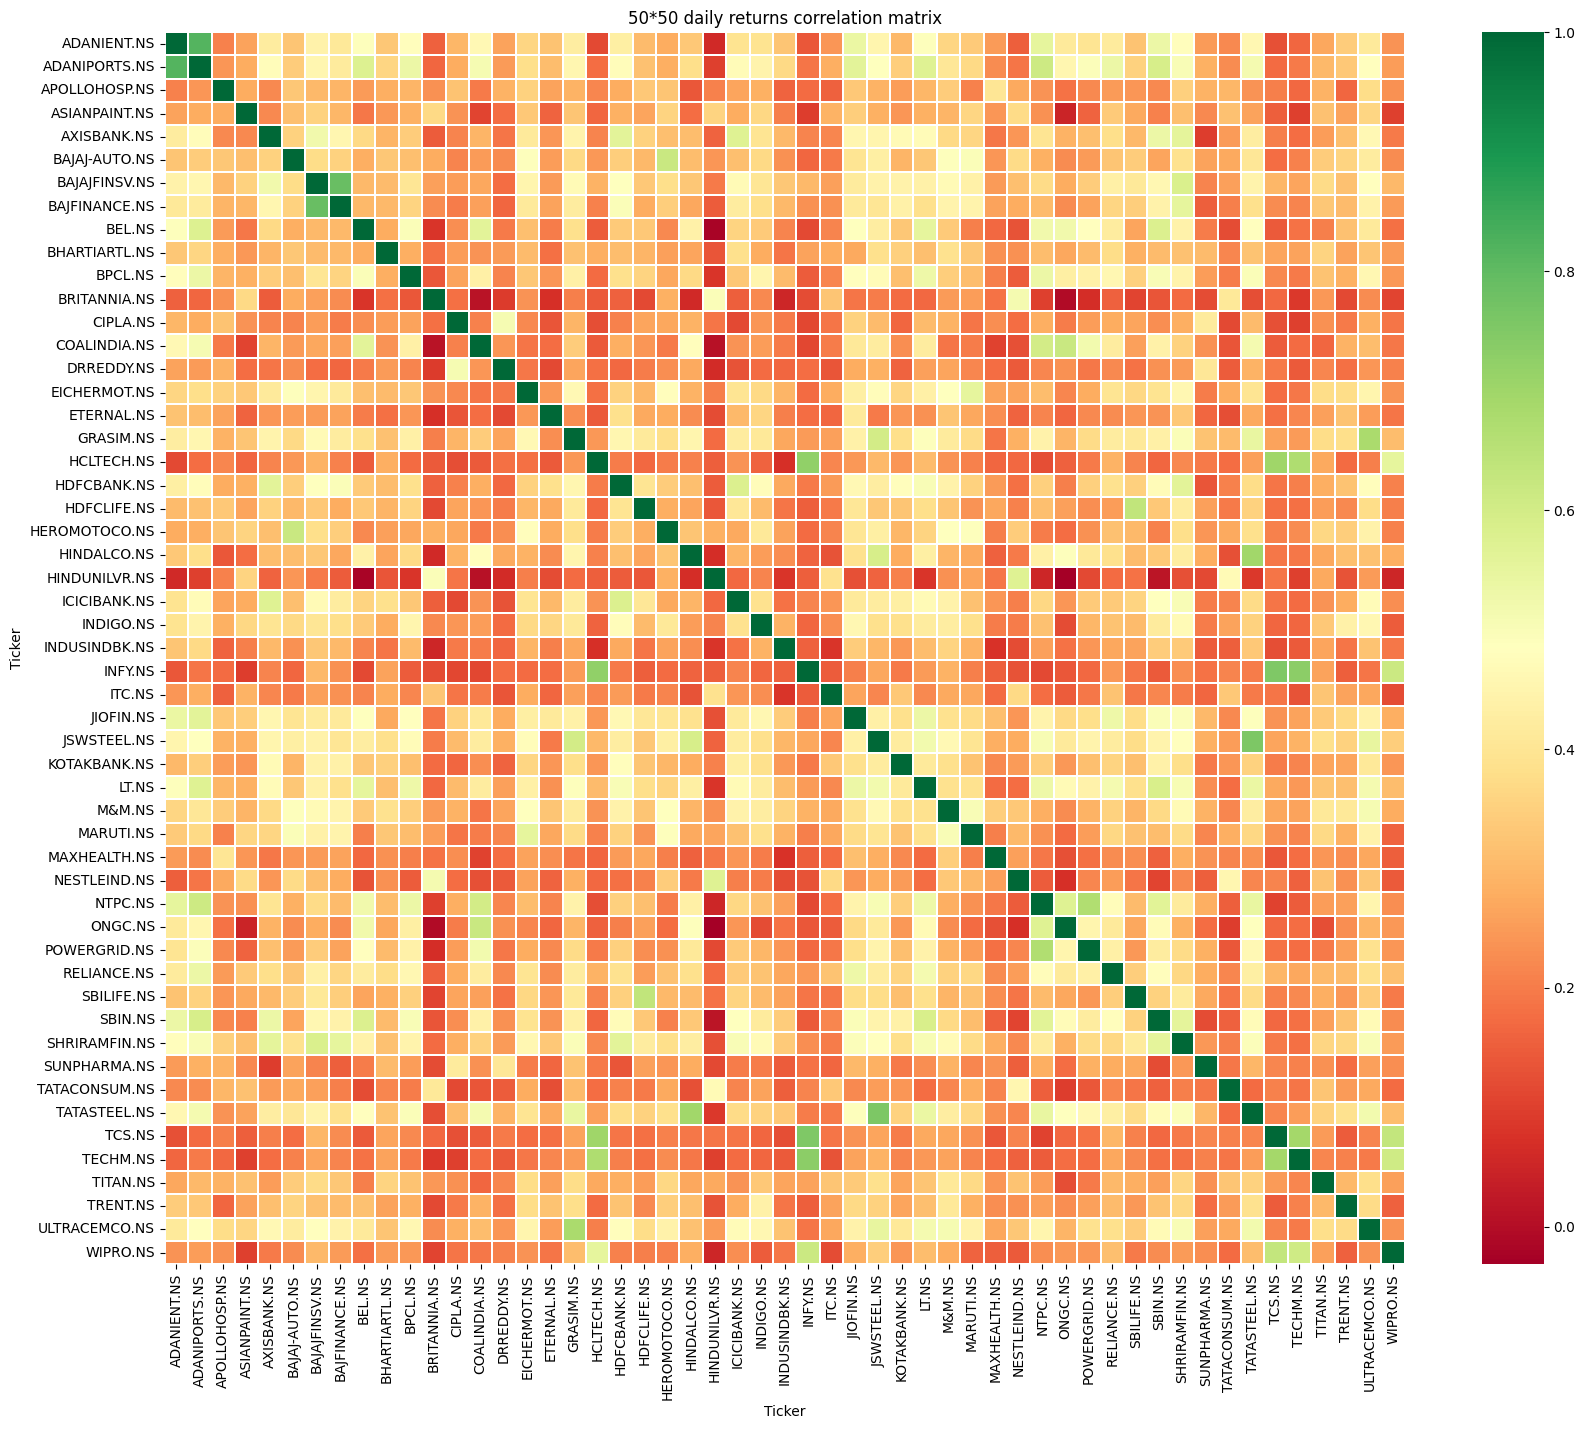

In [11]:
correlation_matrix=log_returns.corr()
plt.figure(figsize=(20,16))
sns.heatmap(correlation_matrix,annot=False,cmap='RdYlGn',linewidth='0.1')
plt.title('50*50 daily returns correlation matrix')
plt.show()

In [42]:
sol = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
pairs = sol.unstack().dropna().sort_values(ascending=False)

high_corr = pairs[abs(pairs) > 0.75]
print("Top Correlated Pairs for Pair-Trading:")
print(high_corr.head())

Top Correlated Pairs for Pair-Trading:
Ticker         Ticker       
ADANIPORTS.NS  ADANIENT.NS      0.817445
BAJFINANCE.NS  BAJAJFINSV.NS    0.787731
TATASTEEL.NS   JSWSTEEL.NS      0.754999
TCS.NS         INFY.NS          0.750477
dtype: float64


In [12]:
sector_mapping = {
    'Financial Services': ['AXISBANK.NS', 'BAJFINANCE.NS', 'BAJAJFINSV.NS', 'HDFCBANK.NS', 'HDFCLIFE.NS', 
    'ICICIBANK.NS', 'INDUSINDBK.NS', 'JIOFIN.NS', 'KOTAKBANK.NS', 'SBILIFE.NS', 'SHRIRAMFIN.NS', 'SBIN.NS'],
    'Information Technology': ['HCLTECH.NS', 'INFY.NS', 'TCS.NS', 'TECHM.NS', 'WIPRO.NS'],
    'Oil, Gas & Consumable Fuels': ['BPCL.NS', 'COALINDIA.NS', 'ONGC.NS', 'RELIANCE.NS'],
    'Automobile and Auto Components': ['BAJAJ-AUTO.NS', 'EICHERMOT.NS', 'HEROMOTOCO.NS', 'M&M.NS', 'MARUTI.NS', 'TMPV.NS'],
    'Healthcare': ['APOLLOHOSP.NS', 'CIPLA.NS', 'DRREDDY.NS', 'MAXHEALTH.NS', 'SUNPHARMA.NS'],
    'Fast Moving Consumer Goods': ['BRITANNIA.NS', 'HINDUNILVR.NS', 'ITC.NS', 'NESTLEIND.NS', 'TATACONSUM.NS'],
    'Metals & Mining': ['ADANIENT.NS', 'HINDALCO.NS', 'JSWSTEEL.NS', 'TATASTEEL.NS'],
    'Power': ['NTPC.NS', 'POWERGRID.NS'],
    'Consumer Durables': ['ASIANPAINT.NS', 'TITAN.NS'],
    'Consumer Services': ['ETERNAL.NS', 'TRENT.NS'],
    'Construction Materials': ['GRASIM.NS', 'ULTRACEMCO.NS'],
    'Services & Infrastructure': ['ADANIPORTS.NS', 'INDIGO.NS', 'LT.NS'],
    'Capital Goods': ['BEL.NS']
}

sector_returns = pd.DataFrame()

for sector, tickers in sector_mapping.items():
    available_tickers = [ticker for ticker in tickers if ticker in log_returns.columns]
    if available_tickers:
        sector_returns[sector] = log_returns[available_tickers].mean(axis=1)

print(sector_returns.head())

            Financial Services  Information Technology  \
DATE                                                     
2024-05-16            0.008423                0.017277   
2024-05-17            0.002613               -0.008818   
2024-05-21           -0.000926                0.001935   
2024-05-22           -0.003536                0.004800   
2024-05-23            0.019144                0.010150   

            Oil, Gas & Consumable Fuels  Automobile and Auto Components  \
DATE                                                                      
2024-05-16                     0.003115                        0.005656   
2024-05-17                     0.006497                        0.010400   
2024-05-21                     0.019237                       -0.003419   
2024-05-22                     0.006557                       -0.000886   
2024-05-23                     0.009660                        0.029249   

            Healthcare  Fast Moving Consumer Goods  Metals & Mining

In [13]:
!pip install pandas-datareader
import pandas_datareader.data as web
from datetime import datetime, timedelta
gdp = web.DataReader('GDP', 'fred', '2024-01-01', '2026-01-01')


gdp_monthly = (
    gdp
    .resample('MS')
    .ffill()
)
gdp_monthly = gdp_monthly.loc['2024-01-01':]
gdp_monthly.head()

,GDP
DATE,
2024-01-01,28708.161
2024-02-01,28708.161
2024-03-01,28708.161
2024-04-01,29147.044
2024-05-01,29147.044


In [14]:
cpi = web.DataReader('CPIAUCSL', 'fred', '2024-01-01', '2026-01-01')

cpi_monthly = (
    cpi
    .resample('MS')
    .ffill()
)
cpi.head()
wpi = web.DataReader('PPIACO', 'fred','2024-01-01', '2026-01-01')

wpi_monthly = (
    wpi
    .resample('MS')
    .ffill()
)
wpi.head()
repo = pd.read_csv("repo_rate.csv")


repo.columns = ['DATE', 'REPO_RATE']


repo['DATE'] = pd.to_datetime(repo['DATE'])


repo.set_index('DATE', inplace=True)


repo_monthly = repo.resample('MS').ffill().dropna()

print(repo_monthly.head())


            REPO_RATE
DATE                 
2024-03-01        6.5
2024-04-01        6.5
2024-05-01        6.5
2024-06-01        6.5
2024-07-01        6.5


C:\Users\vichu\AppData\Local\Temp\ipykernel_21328\2416525334.py:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  repo['DATE'] = pd.to_datetime(repo['DATE'])


In [15]:
macro = (
    cpi_monthly
    .join(gdp_monthly, how='inner')
    .join(wpi_monthly, how='inner')
    .join(repo_monthly, how='inner')
)

macro.columns = ['CPI', 'GDP', 'WPI', 'REPO_RATE']
macro.reset_index()
macro.index=pd.to_datetime(macro.index)
macro_daily=macro.resample('D').ffill()
macro_daily.head()

,CPI,GDP,WPI,REPO_RATE
DATE,,,,
2024-03-01,312.345,28708.161,255.095,6.5
2024-03-02,312.345,28708.161,255.095,6.5
2024-03-03,312.345,28708.161,255.095,6.5
2024-03-04,312.345,28708.161,255.095,6.5
2024-03-05,312.345,28708.161,255.095,6.5


In [16]:
print(sector_returns['Financial Services'])

DATE
2024-05-16    0.008423
2024-05-17    0.002613
2024-05-21   -0.000926
2024-05-22   -0.003536
2024-05-23    0.019144
                ...   
2026-05-11   -0.015660
2026-05-12   -0.025512
2026-05-13   -0.002500
2026-05-14    0.013228
2026-05-15   -0.003577
Name: Financial Services, Length: 496, dtype: float64


In [17]:
macro_linkage1=sector_returns['Financial Services'].corr(macro_daily['REPO_RATE'])
print("Macro Linkage Between Financial Services Sectors and Rerpo Rate:",macro_linkage1)

Macro Linkage Between Financial Services Sectors and Rerpo Rate: -0.010380340945694138


In [18]:
macro_linkage2=sector_returns['Fast Moving Consumer Goods'].corr(macro_daily['CPI'])
print("Macro Linkage Between FMCG Sectors and CPI :",macro_linkage2)

Macro Linkage Between FMCG Sectors and CPI : -0.0271556915806147


In [20]:

oil_ticker = "CL=F" 
oil_data = yf.download(oil_ticker, start="2020-01-01", end="2026-05-15")

print(oil_data.head())

crude_df=oil_data['Close']
crude_df.head()

[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open   Volume
Ticker           CL=F       CL=F       CL=F       CL=F     CL=F
Date                                                           
2020-01-02  61.180000  61.599998  60.639999  61.599998   486873
2020-01-03  63.049999  64.089996  61.130001  61.180000   885861
2020-01-06  63.270000  64.720001  62.639999  63.709999   724236
2020-01-07  62.700001  63.150002  62.110001  62.910000   582649
2020-01-08  59.610001  65.650002  59.150002  62.840000  1205710


Ticker,CL=F
Date,
2020-01-02,61.180000
2020-01-03,63.049999
2020-01-06,63.270000
2020-01-07,62.700001
2020-01-08,59.610001


In [25]:
macro_linkage3=sector_returns['Oil, Gas & Consumable Fuels'].corr(crude_df['CL=F'])
print('Macro Linkage Between  Oil And Fuel and Crude Rate',macro_linkage3)

Macro Linkage Between  Oil And Fuel and Crude Rate -0.013895258950339153
